In [141]:
# digit classifier on mnist dataset using ANN
# dataset used 'https://www.kaggle.com/datasets/oddrationale/mnist-in-csv'

#multiclass classification ANN

In [142]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_test.csv
/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv


In [143]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [144]:
Train = pd.read_csv('/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv')
Test = pd.read_csv('/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_test.csv')

In [145]:
Train.shape

(60000, 785)

In [146]:
Train.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [147]:
X_train = Train.iloc[:,1:]
Y_train = Train['label']

In [148]:
X_train.head()

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [149]:
Y_train.head()

0    5
1    0
2    4
3    1
4    9
Name: label, dtype: int64

In [150]:
X_test = Test.iloc[:,1:]
Y_test = Test.iloc[:,0]

In [151]:
X_train.shape

(60000, 784)

In [152]:
digit =np.reshape( X_train.iloc[0,:],(28,28))

In [153]:
import matplotlib.pyplot as plt

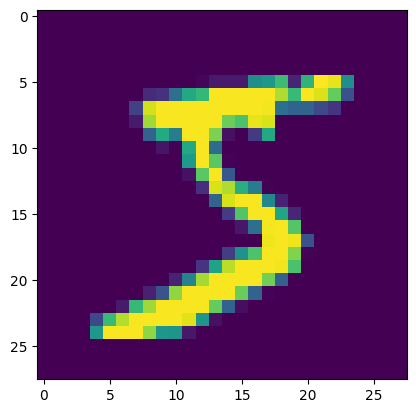

In [154]:
plt.imshow(digit)

In [155]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 784 entries, 1x1 to 28x28
dtypes: int64(784)
memory usage: 358.9 MB


In [156]:
X_train.min().min()

0

In [157]:
X_train.max().max()

255

In [158]:
#data is between 0 and 255 make it between 0 to 1
X_train = X_train/255
X_test = X_test/255

In [159]:
model = Sequential()

model.add(Dense(128,activation='relu',input_shape=(784,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [160]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [161]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [162]:
history = model.fit(X_train,Y_train,epochs=50,validation_split=0.2)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9225 - loss: 0.2680 - val_accuracy: 0.9590 - val_loss: 0.1412
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9647 - loss: 0.1151 - val_accuracy: 0.9647 - val_loss: 0.1193
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9757 - loss: 0.0789 - val_accuracy: 0.9642 - val_loss: 0.1224
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9805 - loss: 0.0597 - val_accuracy: 0.9735 - val_loss: 0.0990
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9846 - loss: 0.0461 - val_accuracy: 0.9726 - val_loss: 0.1053
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9882 - loss: 0.0358 - val_accuracy: 0.9688 - val_loss: 0.1165
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9896 - loss: 0.0318 - val_accuracy: 0.9761 - val_loss: 0.0980
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9921 - loss: 0.0246 -

In [163]:
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [164]:
y_prob

array([[1.8074116e-23, 2.4141723e-20, 4.1757215e-22, ..., 9.9999994e-01,
        5.3146470e-24, 1.1326513e-15],
       [0.0000000e+00, 5.6562340e-21, 9.9999994e-01, ..., 1.9224917e-29,
        4.4664711e-27, 0.0000000e+00],
       [1.0380448e-21, 9.9999994e-01, 1.5964965e-11, ..., 6.0901004e-09,
        3.7015519e-11, 1.2077760e-17],
       ...,
       [0.0000000e+00, 1.4012124e-29, 8.5394725e-37, ..., 5.6812260e-23,
        8.3471651e-29, 3.0684123e-19],
       [2.0039793e-34, 1.1481564e-36, 0.0000000e+00, ..., 0.0000000e+00,
        3.1286090e-19, 9.0330055e-31],
       [9.8825938e-23, 1.6181243e-34, 2.1469510e-24, ..., 0.0000000e+00,
        5.1805957e-23, 6.1090413e-35]], shape=(10000, 10), dtype=float32)

In [165]:
y_prob.shape

(10000, 10)

In [166]:
y_pred = y_prob.argmax(axis=-1)

In [167]:
y_pred

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [168]:
from sklearn.metrics import accuracy_score

In [169]:
accuracy_score(Y_test,y_pred)

0.9827

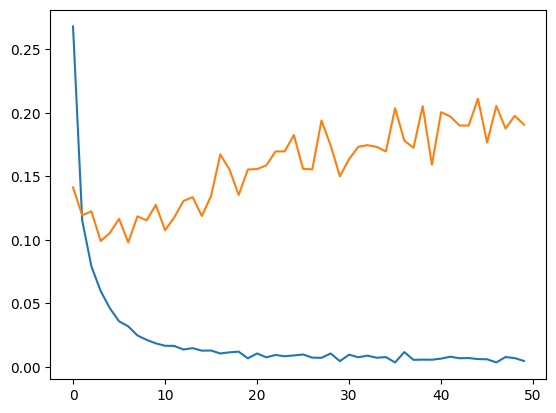

In [171]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

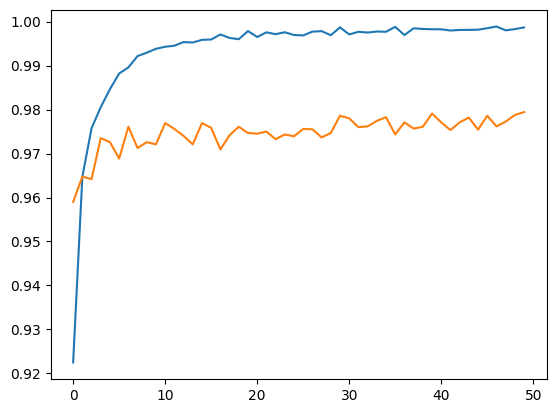

In [173]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])